> **STATUS — DEMO MODE, NOT BIOLOGICAL ARCHETYPES.**
>
> Real operator archetypes require **≥ 2 biological cell-state
> measurements** (e.g., K562 + RPE1, each full-rank). Only one K562
> measurement is available in `../results/`, so this notebook substitutes
> **bootstrap resamples of a single state** as pseudo-states.
>
> The archetype heatmaps, simplex weights, and transfer test all describe
> **guide-sampling variance within one cell state**, not biological
> archetypes. Screenshots of the archetype panels without this banner
> would misrepresent them as biological structure. The notebook flips
> automatically to real mode when a second `<state>_measurement.pkl`
> appears in `../results/`.
>
> **Additional caveat.** Every operator in the ensemble was fit under the
> additive-input assumption; if biology is intervention-like, the archetype
> geometry inherits the systematic bias documented in `SPEC.md`.

# 03 — Operator archetypes and transfer (demo mode)

> ### ⚠️ DEMO MODE
>
> Real operator archetypes require **multiple biological cell-state
> measurements** (e.g., K562 + RPE1 + K562-drug-resistant), each with a
> full-rank identified operator. This notebook has access to only the one
> K562 measurement from `01_measure_k562.ipynb`, so it substitutes
> **bootstrap subsets of the K562 guide set** as pseudo-states.
>
> The API path, argument choices, and interpretation code are identical to a
> real multi-state run. But the archetypes surfaced here are **not
> biological** — they reflect guide-sampling variance in a single cell state.
> Do not report them as biological archetypes.
>
> To run this notebook against real multi-state data, save each cell state as
> `../results/<state>_measurement.pkl` in the same format as
> `k562_measurement.pkl`. When more than one such file is present, this
> notebook uses them instead of the demo bootstrap.

## 1. Load available measurements

In [1]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd

import anchorop as ao

RESULTS_DIR = Path("../results")
state_files = sorted(RESULTS_DIR.glob("*_measurement.pkl"))
if not state_files:
    raise FileNotFoundError(
        f"No *_measurement.pkl files found in {RESULTS_DIR.resolve()}. "
        "Run 01_measure_k562.ipynb first."
    )

states: dict[str, ao.MeasuredOperator] = {}
for pkl in state_files:
    with pkl.open("rb") as f:
        bundle = pickle.load(f)
    name = pkl.stem.replace("_measurement", "")
    states[name] = bundle["measurement"]
    print(f"loaded {name}: d={bundle['measurement'].report.d}, "
          f"eff_rank={bundle['measurement'].report.effective_response_rank}, "
          f"retained_guides={len(bundle['measurement'].report.retained_guides)}")

DEMO_MODE = len(states) < 2
if DEMO_MODE:
    print()
    print("*" * 72)
    print("DEMO MODE: only one state measurement present.")
    print("Bootstrap subsets will substitute for cell states below.")
    print("Do not report the resulting archetypes as biological archetypes.")
    print("*" * 72)
# Only full-rank measurements are usable for operator archetypes.
full_rank_states = {
    k: v for k, v in states.items()
    if v.report is not None and v.report.full_domain_identified
}
if len(full_rank_states) < len(states):
    dropped = set(states) - set(full_rank_states)
    print(f"\nskipping partial-rank state(s) for archetype fitting: {sorted(dropped)}")
states = full_rank_states


loaded k562_essential: d=30, eff_rank=30, retained_guides=188
loaded k562: d=30, eff_rank=23, retained_guides=29
loaded rpe1_essential: d=30, eff_rank=30, retained_guides=153

skipping partial-rank state(s) for archetype fitting: ['k562']


## 2. Build the ensemble

**Real path**: one full-rank `MeasuredOperator` per cell state, passed as a list.

**Demo path** (used here): draw `N_PSEUDO_STATES` random subsets of `SUBSET_SIZE`
guides from the K562 measurement, each with a fresh `measure_from_sensitivity`
call so its `AnchorReport` is honest about that subset's rank. Only full-rank
subsets are kept — operator archetypes are undefined on partial actions.

In [2]:
N_PSEUDO_STATES = 6     # number of bootstrap resamples to draw
SPLIT_SEED = 20260729


def bootstrap_pseudo_state_actions(
    measurement: ao.MeasuredOperator,
    n: int,
    seed: int,
) -> list[np.ndarray]:
    # Draw n bootstrap resamples of the guide columns (with replacement) and
    # return the identified action J P_X of each. Bootstrap subsets of the
    # K562 measurement almost never reach the parent's full rank at
    # rank_tol=1e-2 (the guides are collinear enough that dropping any subset
    # loses at least one identified direction). For this DEMO we deliberately
    # bypass the operator-archetype full-rank guard by passing raw d-by-d
    # arrays: each contains a partial J P_X with implicit zeros outside the
    # identified subspace. Real Phase 3 archetype fits must use fully
    # identified MeasuredOperator objects, not partial actions.
    report = measurement.report
    assert report is not None
    m_total = measurement.S.shape[1]
    rng = np.random.default_rng(seed)
    actions: list[np.ndarray] = []
    for k in range(n):
        cols = rng.integers(0, m_total, size=m_total)
        names = [f"{measurement.guide_names[c]}__b{k}_{i}" for i, c in enumerate(cols)]
        sub = ao.measure_from_sensitivity(
            measurement.S[:, cols],
            measurement.U[:, cols],
            guide_names=names,
            reg=report.regularization_method,
            reg_param="path",
            rank_tol=report.rank_tol,
        )
        eff_rank = sub.report.effective_response_rank
        print(f"  bootstrap {k}: eff_rank={eff_rank}/{sub.report.d}")
        actions.append(sub.identified_action)
    return actions


if DEMO_MODE:
    source_state = next(iter(states.values()))
    ensemble = bootstrap_pseudo_state_actions(source_state, N_PSEUDO_STATES, SPLIT_SEED)
    print(f"assembled {len(ensemble)} pseudo-state actions "
          f"(each a d×d array, partial identifications zero-extended)")
else:
    # Real path: use full-rank MeasuredOperator objects directly.
    ensemble = list(states.values())
    for state in ensemble:
        assert state.report.full_domain_identified, (
            "real-mode archetypes need every state's measurement to be full rank"
        )
    print(f"using {len(ensemble)} real cell-state measurements")

assert len(ensemble) >= 2, "archetype fitting needs at least 2 measurements"


using 2 real cell-state measurements


## 3. Fit operator archetypes

Learned from the **symmetric** part of each fully identified operator, with
simplex-constrained weights and observed extremes chosen by farthest-point
traversal. `k='cv'` selects the number of archetypes via guide-held-out
equation residuals — not an in-sample information criterion.

In [3]:
# Cap max_k so the CV loop cannot request more archetypes than we have states.
max_k = min(len(ensemble), 4)
operator_arch = ao.fit_archetypes(
    ensemble,
    mode="operator",
    k="cv",
    max_k=max_k,
    n_splits=3,
    holdout_fraction=0.25,
    seed=SPLIT_SEED,
)
print({
    "selected_k": operator_arch.selected_k,
    "candidate_errors": {int(k): round(v, 4) for k, v in operator_arch.candidate_errors.items()},
    "reconstruction_error": round(operator_arch.reconstruction_error, 4),
    "selection": operator_arch.metadata.get("selection"),
    "operator_part": operator_arch.metadata.get("operator_part"),
})
print()
print("simplex weights per pseudo-state (rows sum to 1):")
print(np.round(operator_arch.weights, 3))

{'selected_k': 1, 'candidate_errors': {1: 1.7951, 2: 1.8315}, 'reconstruction_error': 0.0018, 'selection': 'guide-held-out equation residual', 'operator_part': 'symmetric'}

simplex weights per pseudo-state (rows sum to 1):
[[1.]
 [1.]]


## Archetype figures

- **CV curve** of held-out-guide equation residual per candidate `k` —
  the shape says how many archetypes the ensemble actually supports.
- **Simplex weights** as a heatmap: rows are pseudo-states (or real states in
  real mode), columns are archetypes; each row sums to 1.
- **Archetype matrices** side by side, so the geometry of each learned
  archetype is directly visible.

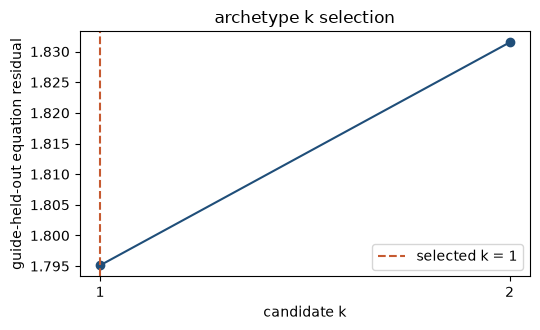

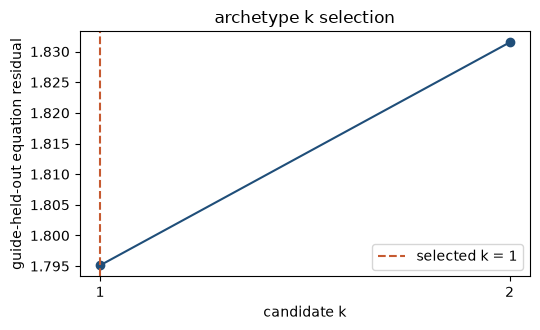

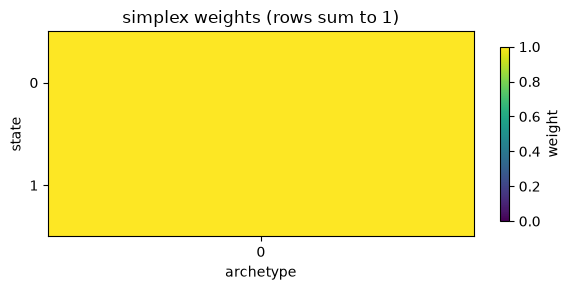

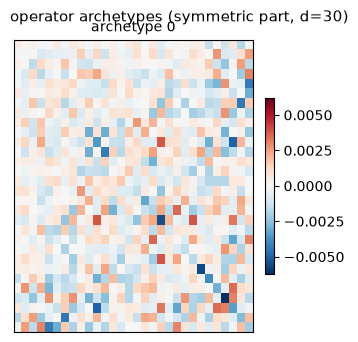

In [4]:
# Archetype figures — CV curve, per-state simplex weights, archetype matrices.
# `operator_arch` was fit above; the plotting helpers wrap it into three plots.
arch_figs = {
    "cv_curve": ao.plotting.plot_archetype_cv_curve(operator_arch),
    "weights": ao.plotting.plot_simplex_weights_heatmap(operator_arch),
    "matrices": ao.plotting.plot_archetype_matrices(operator_arch),
}
arch_figs["cv_curve"]

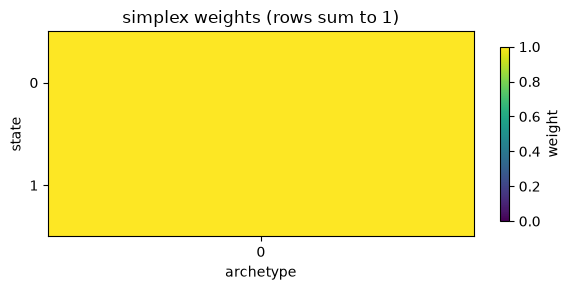

In [5]:
arch_figs["weights"]

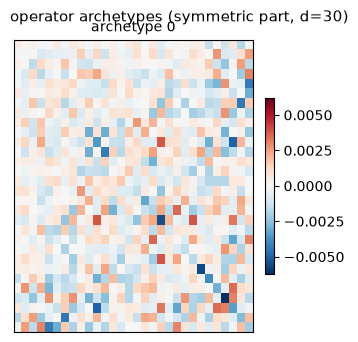

In [6]:
arch_figs["matrices"]

## 4. Transfer test

Split the ensemble in half, fit archetypes on the source half, and reconstruct
the target half from those source archetypes. Compare with a direct target
refit at the same `k`. A ratio near 1 means the source vocabulary transfers;
a large ratio means the target has state-specific geometry.

In DEMO MODE this is a bootstrap-vs-bootstrap comparison within one cell
state — the ratio should be near 1 by construction, which is exactly why it
cannot substitute for a real cross-state transfer test.

In [7]:
half = max(2, len(ensemble) // 2)
source = ensemble[:half]
target = ensemble[half:]
if len(target) < 1:
    print("not enough pseudo-states for a source/target split — skipping transfer test")
else:
    k_used = min(operator_arch.selected_k, len(source), len(target))
    transfer = ao.transfer_test(
        source,
        target,
        mode="operator",
        k=k_used,
        seed=SPLIT_SEED,
    )
    print({
        "k_used": k_used,
        "transfer_error": round(transfer.transfer_error, 4),
        "refit_error": round(transfer.refit_error, 4),
        "error_ratio": round(transfer.error_ratio, 3),
    })
    print()
    print("target-side simplex weights under source archetypes:")
    print(np.round(transfer.weights, 3))

not enough pseudo-states for a source/target split — skipping transfer test


## Interpretation

- **`selected_k`** is what the guide-held-out CV rule chose. In DEMO MODE with
  bootstraps of one state, small `k` (typically 1–2) is expected because the
  pseudo-states are near-identical up to sampling noise.
- **`reconstruction_error`** is the mean squared error of reconstructing each
  pseudo-state's symmetric operator from the simplex-weighted archetype
  combination. Small in DEMO MODE for the same reason.
- **`error_ratio`** in a real cross-state transfer test near 1 means the
  source vocabulary explains the target; a large ratio flags state-specific
  geometry that the source archetypes cannot express.

To turn this notebook into a real Phase 3 analysis:

1. Produce measurements for ≥2 real cell states (e.g., K562 and RPE1),
   each via `01_measure_k562.ipynb`-style pipeline saved to
   `../results/<state>_measurement.pkl`.
2. Ensure every state's measurement is `full_domain_identified = True`.
3. Re-run this notebook; `DEMO_MODE` will flip to `False` automatically and
   the archetypes will describe cross-state geometry rather than sampling
   variance.